In [1]:
!pip install torchmetrics pandas datasets numpy torchmetrics scikit-learn seaborn torchcodec torchaudio librosa ipywidgets torchvision timm

## Imports

In [1]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset, load_from_disk
from torch.utils.data import DataLoader
from torchvision.transforms.functional import resize
import timm
from tqdm import tqdm
import librosa
import numpy as np

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 256
NUM_WORKERS = 32
EPOCHS = 20
LR = 1e-4
WEIGHT_DECAY = 1e-2
SPEC_HEIGHT  = 128   # mel bins
SPEC_WIDTH   = 256   # time frames after fixed-length normalisation
TASK = "binary"
NUM_CLASSES = 1
VIT_MODEL = "vit_base_patch16_224"
PRETRAINED = True
FREEZE_BACKBONE = False
CHECKPOINT_PATH = "models/best_vit_drone.pth"

## Load dataset

In [3]:
dataset = load_dataset("Hibou-Foundation/ds_1_MAT-AllTEST_melspectogram")
dataset = dataset.with_format("torch", columns=["audio", "label"])
# Take only n% of the dataset
n_instance = 0.1
dataset["train"] = dataset["train"].shuffle(seed=42).select(range(int(n_instance * len(dataset["train"]))))
dataset["val"] = dataset["val"].shuffle(seed=42).select(range(int(n_instance * len(dataset["val"]))))
print("\nDataset splits:")
print({k: v.shape for k, v in dataset.items()})
# Drop column "raw_audio"
# dataset = dataset.remove_columns("raw_audio")
print("\nDataset features:")
print(dataset["train"].features)

Resolving data files:   0%|          | 0/43 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/43 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/43 [00:00<?, ?it/s]


Dataset splits:
{'train': (63682, 2), 'val': (15882, 2)}

Dataset features:
{'audio': List(List(List(Value('float64')))), 'label': ClassLabel(names=['other', 'drone'])}


## Collate Fn

In [4]:
def resize_spec(spec: torch.Tensor, height: int, width: int) -> torch.Tensor:
    """
    spec : [1, H, T]  — any size
    Returns [1, height, width] via bilinear interpolation.
    Works regardless of how small T is relative to target width.
    """
    # interpolate expects [B, C, H, W]
    spec = spec.unsqueeze(0)                              # [1, 1, H, T]
    spec = torch.nn.functional.interpolate(
        spec,
        size=(height, width),
        mode="bilinear",
        align_corners=False,
    )
    return spec.squeeze(0)                                # [1, height, width]

def collate_fn(batch):
    inputs, labels = [], []
    for item in batch:
        mel = item["audio"]
        mel = resize_spec(mel, SPEC_HEIGHT, SPEC_WIDTH)          # [1, 128, SPEC_WIDTH]
        inputs.append(mel)
        labels.append(item["label"])

    inputs = torch.stack(inputs)                     # [B, 1, 128, SPEC_WIDTH]

    labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)   # [B, 1]

    return inputs, labels

In [5]:
train_loader = DataLoader(
    dataset["train"],
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=True,
)
valid_loader = DataLoader(
    dataset["val"],
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=True,
)

# x, y = next(iter(train_loader))
# print(f"Batch shapes  →  X: {x.shape}  Y: {y.shape}")
# Expected: X: [B, 1, 128, 256]   Y: [B, 1]

## Model Declaration

In [6]:
class SpectrogramViT(nn.Module):
    def __init__(
        self,
        model_name: str = VIT_MODEL,
        num_classes: int = NUM_CLASSES,
        img_size: tuple = (SPEC_HEIGHT, SPEC_WIDTH),
        pretrained: bool = PRETRAINED,
        freeze_backbone: bool = FREEZE_BACKBONE,
    ):
        super().__init__()
        # Channel expansion
        self.channel_expand = nn.Conv2d(1, 3, kernel_size=1, bias=False)

        self.vit = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=num_classes,
            img_size=img_size,
            in_chans=3,
        )

        if freeze_backbone:
            for name, param in self.vit.named_parameters():
                if "head" not in name:
                    param.requires_grad = False

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x : [B, 1, H, W]  →  logits : [B, num_classes]"""
        x = self.channel_expand(x)      # [B, 3, H, W]
        return self.vit(x)

## Loss, Model, Warmup & Metrics

In [7]:
criterion = nn.BCEWithLogitsLoss()
True
def compute_accuracy(logits: torch.Tensor, labels: torch.Tensor) -> float:
    preds = (torch.sigmoid(logits) > 0.5).float()
    return (preds == labels).float().mean().item()

model = SpectrogramViT().to(DEVICE)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

warmup_epochs = 1
scheduler = optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[
        optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=warmup_epochs),
        optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS - warmup_epochs),
    ],
    milestones=[warmup_epochs],
)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

/tmp/ipykernel_17683/1434043957.py:24: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))


## Training Loop

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss, total_acc = 0.0, 0.0

    for x, y in tqdm(loader, desc="  Train", leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()

        with torch.autocast(device_type=DEVICE, dtype=torch.float16):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_acc  += compute_accuracy(logits.detach(), y)

    n = len(loader)
    return total_loss / n, total_acc / n

@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss, total_acc = 0.0, 0.0

    for x, y in tqdm(loader, desc="  Valid", leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.autocast(device_type=DEVICE, dtype=torch.float16):
            logits = model(x)
            loss = criterion(logits, y)
        total_loss += loss.item()
        total_acc  += compute_accuracy(logits, y)

    n = len(loader)
    return total_loss / n, total_acc / n

In [10]:
best_val_acc = 0.0
print(f"\nTraining on {DEVICE}  |  {EPOCHS} epochs\n{'─'*50}")

for epoch in range(1, EPOCHS + 1):
    print(f"Epoch [{epoch:02d}/{EPOCHS}]")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
    val_loss,   val_acc   = validate(model, valid_loader, criterion)
    scheduler.step()

    print(
        f"  Train  loss={train_loss:.4f}  acc={train_acc*100:.2f}%\n"
        f"  Valid  loss={val_loss:.4f}    acc={val_acc*100:.2f}%"
    )

    with open("training_history.txt", "a") as f:
        f.write(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | "
                f"Val Acc: {val_acc:.4f}\n")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "val_acc": val_acc,
            },
            CHECKPOINT_PATH,
        )
        print(f"Saved best model  (val_acc={val_acc*100:.2f}%)")

print(f"\nTraining complete. Best val acc: {best_val_acc*100:.2f}%")


Training on cuda  |  20 epochs
──────────────────────────────────────────────────
Epoch [01/20]


  Train  loss=0.1137  acc=95.56%
  Valid  loss=0.0742    acc=97.84%
Saved best model  (val_acc=97.84%)
Epoch [02/20]


  Train  loss=0.1056  acc=96.26%
  Valid  loss=0.0657    acc=97.95%
Saved best model  (val_acc=97.95%)
Epoch [03/20]


  Train  loss=0.0499  acc=98.39%
  Valid  loss=0.0557    acc=98.43%
Saved best model  (val_acc=98.43%)
Epoch [04/20]


  Train  loss=0.0348  acc=98.86%
  Valid  loss=0.0550    acc=98.48%
Saved best model  (val_acc=98.48%)
Epoch [05/20]


...

  Train  loss=0.0002  acc=99.99%
  Valid  loss=0.0849    acc=99.05%
Epoch [17/20]


  Train  loss=0.0002  acc=99.99%
  Valid  loss=0.0853    acc=99.08%
Epoch [18/20]


  Train  loss=0.0002  acc=99.99%
  Valid  loss=0.0874    acc=99.05%
Epoch [19/20]


  Train  loss=0.0002  acc=99.99%
  Valid  loss=0.0883    acc=99.05%
Epoch [20/20]


  Train  loss=0.0001  acc=99.99%
  Valid  loss=0.0885    acc=99.05%

Training complete. Best val acc: 99.10%


In [11]:
model = SpectrogramViT().to(DEVICE)
ckpt  = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

def convert_to_mel_spectrogram(data):
    mel = librosa.feature.melspectrogram(
        y=data,
        sr=16000,
        n_fft=1025,
        hop_length=256,
        n_mels=128,
        fmin=20,
        fmax=8000,
        power=2.0
    )
     # Convert to log scale (dB)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    # Normalize
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)
    # Convert to torch tensor: [1, n_mels, time]
    mel_db = torch.tensor(mel_db).unsqueeze(0)

    return mel_db


def predict(raw_audio):
    """
    mel_tensor : [1, 128, T]  (raw output of convert_to_mel_spectrogram)
    Returns     : {"label": int, "confidence": float}
    """
    mel_tensor = convert_to_mel_spectrogram(raw_audio)
    x = resize_spec(mel_tensor, SPEC_HEIGHT, SPEC_WIDTH).unsqueeze(0).to(DEVICE)  # [1, 1, H, W]
    with torch.no_grad():
        logit = model(x)   # [1, 1]
        prob  = torch.sigmoid(logit).item()
        label = int(prob >= 0.5)
        return {"label": label, "confidence": prob if label == 1 else 1 - prob}

## Evaluation on test set

In [12]:
ds_all_tests = load_dataset("Hibou-Foundation/all_tests_ds_3")

In [13]:
from torchmetrics.classification import BinaryF1Score, BinaryAccuracy, ConfusionMatrix

metrics = {}

for split in ds_all_tests:
    print(f"Evaluating on split: {split}")
    target = []
    preds = []

    for item in tqdm(ds_all_tests[split], desc=f"  {split}", leave=False):
        raw_audio = item["audio"]["array"]
        true_label = item["label"]
        pred = predict(raw_audio)
        target.append(true_label)
        preds.append(pred["label"])

    f1_score = BinaryF1Score()(torch.tensor(preds), torch.tensor(target))
    confusion_matrix = ConfusionMatrix(task="binary", num_classes=2)(torch.tensor(preds), torch.tensor(target))
    acc = BinaryAccuracy()(torch.tensor(preds), torch.tensor(target))

    metrics[split] = {
        "accuracy": acc.item(),
        "f1_score": f1_score.item(),
        "confusion_matrix": confusion_matrix.cpu().numpy(),
    }
    print(f"Split: {split}  |  Accuracy: {acc.item()*100:.2f}%  |  F1 Score: {f1_score.item():.4f}")

Evaluating on split: drone_test


Split: drone_test  |  Accuracy: 85.11%  |  F1 Score: 0.7906
Evaluating on split: drone_test_2


Split: drone_test_2  |  Accuracy: 94.08%  |  F1 Score: 0.9695
Evaluating on split: parabole1


Split: parabole1  |  Accuracy: 98.37%  |  F1 Score: 0.9870
Evaluating on split: parabole2


Split: parabole2  |  Accuracy: 100.00%  |  F1 Score: 1.0000
Evaluating on split: parabole3


Split: parabole3  |  Accuracy: 86.91%  |  F1 Score: 0.9130
Evaluating on split: parabole4


Split: parabole4  |  Accuracy: 93.63%  |  F1 Score: 0.9107
Evaluating on split: parabole5


Split: parabole5  |  Accuracy: 96.39%  |  F1 Score: 0.7273
Evaluating on split: parabole6


Split: parabole6  |  Accuracy: 91.52%  |  F1 Score: 0.8539
Evaluating on split: parabole7


Split: parabole7  |  Accuracy: 95.89%  |  F1 Score: 0.9626


## Confusion Matrix and F1 Score Visualization

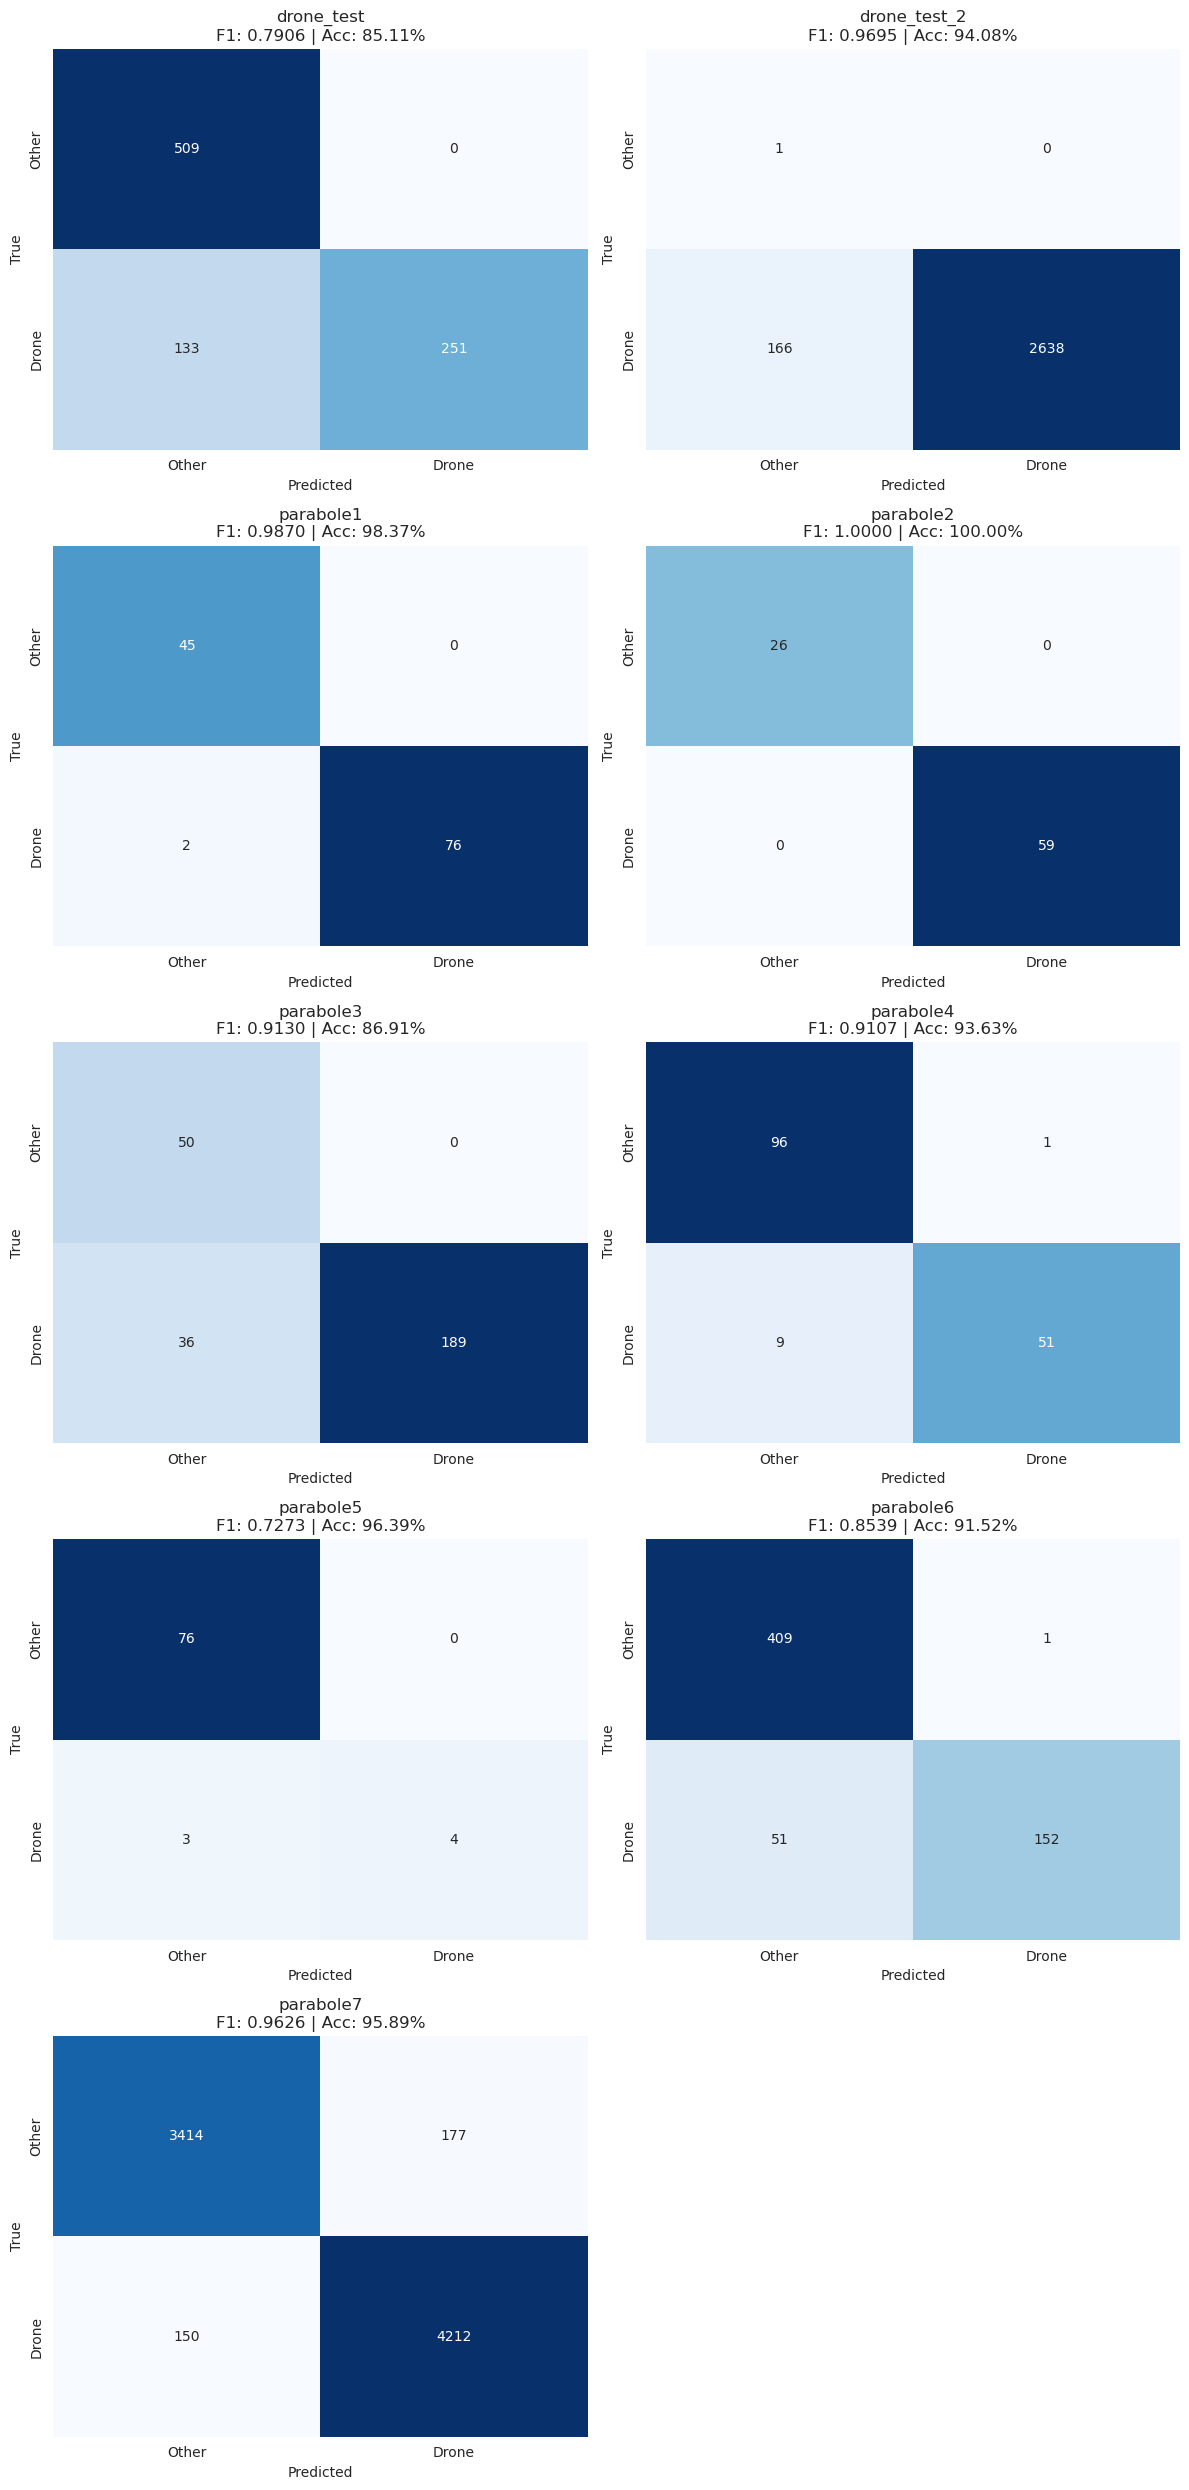

In [14]:
import math
import seaborn as sns
import matplotlib.pyplot as plt

n_cols = 2
n_rows = math.ceil(len(metrics) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()

for ax, (split, m) in zip(axes, metrics.items()):
    sns.heatmap(
        m["confusion_matrix"],
        annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax
    )
    ax.set_title(f"{split}\nF1: {m['f1_score']:.4f} | Acc: {m['accuracy']*100:.2f}%")
    ax.set_xticks([0.5, 1.5])
    ax.set_yticks([0.5, 1.5])
    ax.set_xticklabels(["Other", "Drone"])
    ax.set_yticklabels(["Other", "Drone"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

for ax in axes[len(metrics):]:
    ax.remove()

plt.tight_layout()
plt.show()

## Upload Models to HuggingFace Hub
We only save the model for inference in the Hibou Server Project. No versionning is done here.

In [15]:
from huggingface_hub import create_repo, upload_file

repo_id = "Hibou-Foundation/audio-models"
create_repo(repo_id, exist_ok=True)

upload_file(
    path_or_fileobj=CHECKPOINT_PATH,
    path_in_repo="timm.pt",
    repo_id=repo_id,
)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/Hibou-Foundation/audio-models/commit/e5d29628602e5b5fe9e32edbfc89cc2a3fbf7b8d', commit_message='Upload timm.pt with huggingface_hub', commit_description='', oid='e5d29628602e5b5fe9e32edbfc89cc2a3fbf7b8d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Hibou-Foundation/audio-models', endpoint='https://huggingface.co', repo_type='model', repo_id='Hibou-Foundation/audio-models'), pr_revision=None, pr_num=None)